# What is in the conditioning space?

The Class-Encoder replaces Stable Diffusion's text encoder, mapping a one-hot class
vector into the space the UNet expects for conditioning. Those one-hot vectors are
mutually orthogonal by construction — `cat` starts exactly as far from `dog` as from
`truck` — and the model never sees the words, only indices.

This notebook asks what the encoder puts into that space after transfer learning, and
answers **without generating a single image**: the encoder turns out to be an affine
map, so class embeddings can be read straight from the weights.

Three questions in order:

1. how much of the conditioning is **shared** by every class, and how much
   distinguishes them?
2. does the residual carry **structure**, or is it noise?
3. is that structure **semantic**, or something else?

In [1]:
%matplotlib inline

import os
import sys

# The project's code uses paths relative to the repository root. The check keeps
# the cell idempotent when re-run.
if os.path.basename(os.getcwd()) == "Notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from scripts.generator_part.conditioning.lib import common, conditioning, plotting

EXP = "xAI"

# Encoder epoch selected by the paper's optimisation, per dataset.
ENCODERS = {"cifar10": 31, "cifar100": 41, "pathmnist": 28,
            "dermamnist": 5, "bloodmnist": 35, "retinamnist": 31}


def load(dataset):
    """The stored conditioning-space analysis for one dataset."""
    return np.load(os.path.join(
        common.results_dir(EXP, dataset, "conditioning"),
        f"epoch{ENCODERS[dataset]}.npz"))


print("datasets:", ", ".join(ENCODERS))

2026-09-24 16:42:05.600525: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-24 16:42:05.645315: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-24 16:42:05.646430: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-24 16:42:09.410406: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


datasets: cifar10, cifar100, pathmnist, dermamnist, bloodmnist, retinamnist


## 1. The encoder is an affine map

`Models/class_encoder.py` chains two `Dense` layers with no activation:

    Dense(500) -> Dense(76800, use_bias=False) -> Reshape(100, 768)

With nothing non-linear in between, the two matrices collapse into one:

    context(x) = (x W1 + b1) W2 = x E + u,    where  E = W1 W2,  u = b1 W2

Three consequences follow. The context of class *c* is row *c* of `E` plus `u`, and
can be read straight from the weights. The unconditional context used by
classifier-free guidance is an all-zeros input, hence exactly `u`. And the direction
guidance amplifies is `E[c]` — the only channel through which the class enters
generation.

Every run of `scripts/generator_part/conditioning/run_conditioning.py` re-verifies this before computing anything, and
refuses to proceed if the closed form and the model disagree. Not a formality: the
check revealed that the *model* is the less accurate of the two, because TensorFlow
uses TF32 for matmuls on recent GPUs, dropping the mantissa to 10 bits. The closed
form sits `3.9e-6` from a `float64` reference, the model `4.1e-4`.

     dataset  classes    shared   residual   eff. rank   max
     cifar10       10    96.6%      3.4%        5.33     9
    cifar100      100    97.7%      2.3%       15.35    99
   pathmnist        9    87.4%     12.6%        4.36     8
  dermamnist        7    87.0%     13.0%        1.26     6
  bloodmnist        8    98.8%      1.2%        3.56     7
 retinamnist        5    93.3%      6.7%        1.29     4


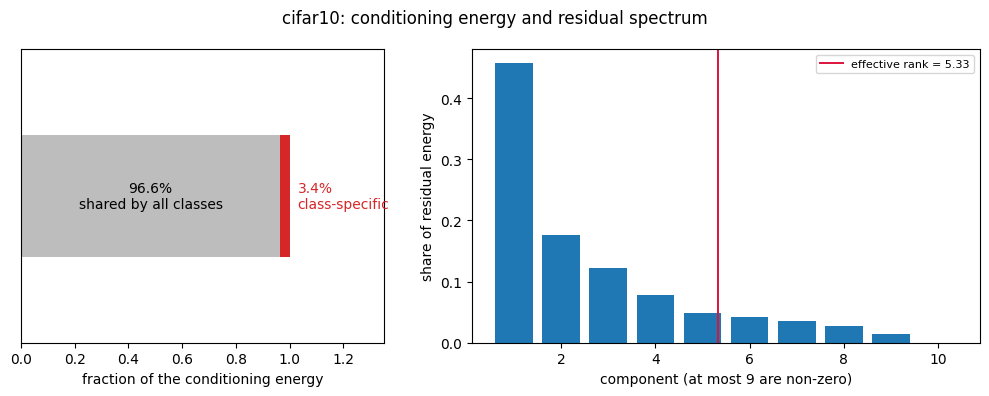

In [2]:
print(f"{'dataset':>12} {'classes':>8} {'shared':>9} {'residual':>10} "
      f"{'eff. rank':>11} {'max':>5}")
for dataset in ENCODERS:
    space = load(dataset)
    n_classes = len(space["labels"])
    print(f"{dataset:>12} {n_classes:>8} {float(space['shared_energy']):>8.1%} "
          f"{float(space['residual_energy']):>9.1%} "
          f"{float(space['effective_rank']):>11.2f} {n_classes - 1:>5}")

space = load("cifar10")
fig = plotting.energy_spectrum(
    float(space["shared_energy"]), space["singular_values"],
    float(space["effective_rank"]),
    title="cifar10: conditioning energy and residual spectrum")
display(fig)
plt.close(fig)

Between 87% and 99% of the conditioning is **identical for every class**. Whatever
tells `cat` from `truck` lives in the few percent that remain.

The two columns do not measure the same thing, and the difference matters. DermaMNIST
has the **largest** residual of all six (13.0%) and the **lowest** effective rank
(1.26): plenty of discriminative energy, all of it pointing in a single direction.
BloodMNIST is the opposite — the smallest residual (1.2%) spread over 3.56 effective
directions — and generates well.

So the amount of class-specific signal predicts nothing on its own. How it is
distributed does, and Result 4 makes that quantitative.

## 2. Is the residual structured, or noise?

The raw cosines between class directions are useless for this: dominated by the
shared component, they sit around +0.96 for every pair, making `cat`-`dog` look as
similar as `cat`-`truck`. Subtracting the mean exposes what actually separates the
classes:

    E[c] = mean + R[c]

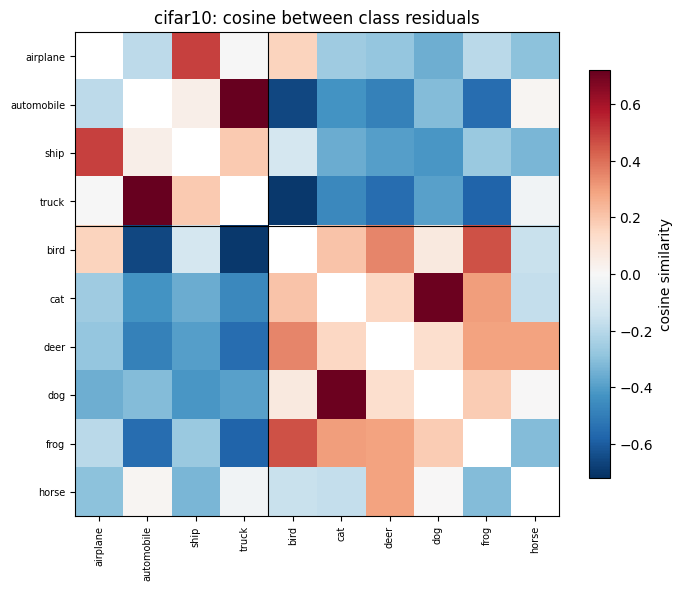

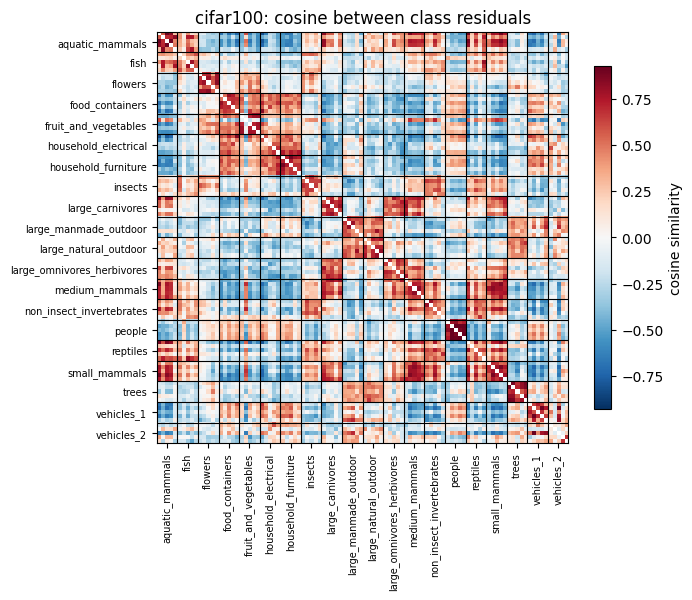

In [3]:
for dataset in ("cifar10", "cifar100"):
    space = load(dataset)
    labels = [str(label) for label in space["labels"]]
    groups = common.SEMANTIC_GROUPS.get(dataset)
    ids = common.group_ids(labels, groups) if groups else None

    fig = plotting.cosine_heatmap(
        space["cos_residuals"], labels, ids,
        list(groups) if groups else None,
        title=f"{dataset}: cosine between class residuals")
    display(fig)
    plt.close(fig)

Four quadrants. Vehicles and animals each form a red block, and the crossing
quadrants are distinctly **blue**: the two groups are not merely different, they are
anti-aligned. The strongest pairs are `automobile`-`truck` and `cat`-`dog`. And
`horse` is the outlier — pale row, pale column, the least integrated class in its own
group.

On CIFAR-100 the twenty superclasses appear as blocks along the diagonal, and above
them a second level nobody supplied: indoor objects cluster together, and so do
mammals and reptiles. A nested taxonomy that CIFAR-100 does not even define, emerging
from a hundred mutually orthogonal vectors.

### But "it looks structured" is not a measurement

Ten classes give ten closest-pairs, and among ten items some apparent structure
arises by chance. Worse, the eye is generous: we already know which pairs *should*
go together, so we see them.

The test turns it into a number. Group the classes by an **external** taxonomy — one
defined by the dataset, not chosen by us after looking at the cosines — and measure
how much closer classes are to their own group than to the others. Then shuffle the
group labels a few thousand times and ask how often chance does as well.

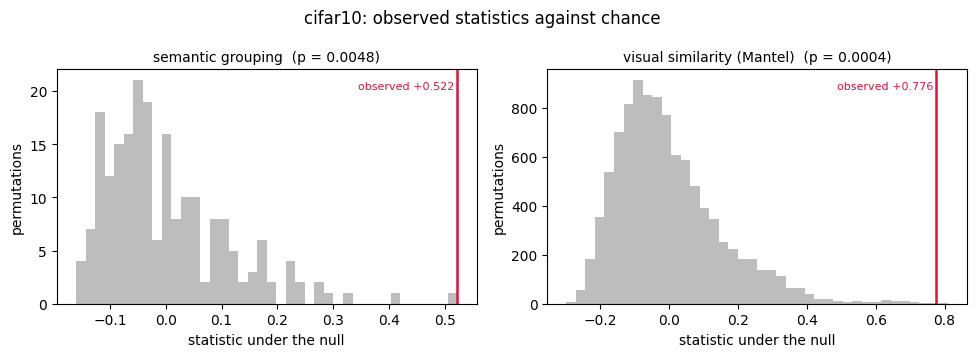

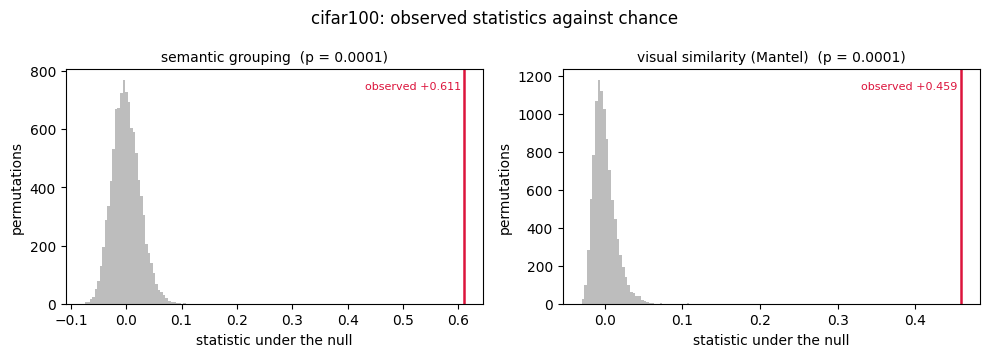

In [4]:
for dataset in ("cifar10", "cifar100"):
    space = load(dataset)
    tests = [
        {"name": "semantic grouping", "null": space["perm_null"],
         "observed": float(space["perm_observed"]),
         "p_value": float(space["perm_p_value"])},
        {"name": "visual similarity (Mantel)", "null": space["mantel_null"],
         "observed": float(space["mantel_correlation"]),
         "p_value": float(space["mantel_p_value"])},
    ]
    fig = plotting.null_distributions(
        tests, title=f"{dataset}: observed statistics against chance")
    display(fig)
    plt.close(fig)

## 3. Is the structure semantic, or something else?

Both tests so far rest on a taxonomy **we** chose. On CIFAR the choices are canonical
and defensible — vehicles/animals, the twenty official superclasses — but picking the
reference is itself a way of being wrong, and BloodMNIST proves it.

BloodMNIST has no official coarse labels, so we used the primary morphological
division in haematology: granulocytes against the rest. The test returned
**p = 0.77**, with a *negative* separation — classes in the same group were slightly
**less** similar to each other than to classes outside it.

The tempting move is to try another grouping. With 35 possible partitions, searching
for one that fits guarantees finding it, and the resulting p-value would be worthless.
The honest fix is to stop using taxonomies and **measure** the reference instead: the
visual similarity of the **real images**, computed from the pixels, with no choice
left to us.

The two matrices are then compared with a **Mantel test**. An ordinary correlation
p-value would be wrong here, because the entries of a similarity matrix are not
independent observations — every class appears in n−1 cells. The Mantel null shuffles
the class order of one matrix, preserving its internal structure while destroying the
correspondence between the two.

     dataset   Mantel r        p
     cifar10     +0.776   0.0004
    cifar100     +0.459   0.0001
   pathmnist     +0.242   0.0767
  dermamnist     +0.828   0.0216
  bloodmnist     +0.878   0.0001
 retinamnist     +0.735   0.0919


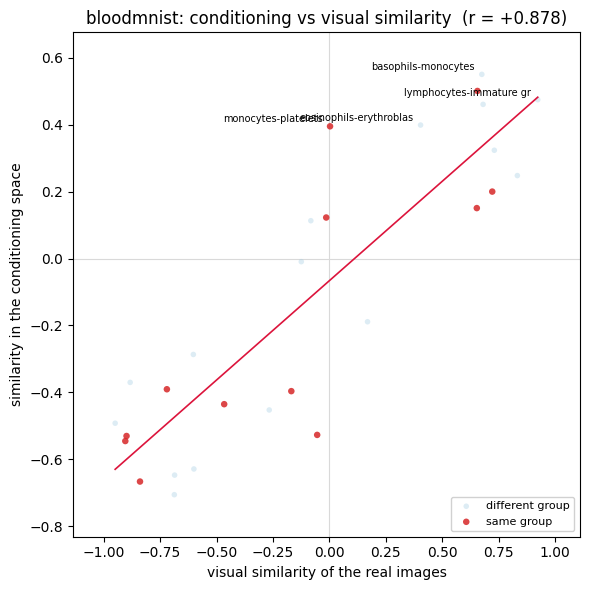

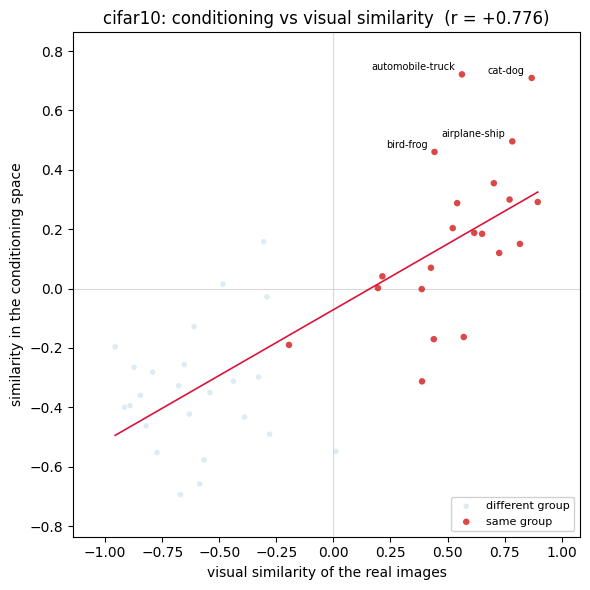

In [5]:
print(f"{'dataset':>12} {'Mantel r':>10} {'p':>8}")
for dataset in ENCODERS:
    space = load(dataset)
    print(f"{dataset:>12} {float(space['mantel_correlation']):>+10.3f} "
          f"{float(space['mantel_p_value']):>8.4f}")

for dataset in ("bloodmnist", "cifar10"):
    space = load(dataset)
    labels = [str(label) for label in space["labels"]]
    groups = common.SEMANTIC_GROUPS.get(dataset)
    ids = common.group_ids(labels, groups) if groups else None

    fig = plotting.mantel_scatter(
        space["cos_visual"], space["cos_residuals"], labels,
        correlation=float(space["mantel_correlation"]),
        group_ids=ids, annotate=4,
        title=f"{dataset}: conditioning vs visual similarity")
    display(fig)
    plt.close(fig)

## 4. From description to prediction

Everything so far *describes* the conditioning space. The effective rank turns out to
do more.

It appeared in section 1 as a way of saying how evenly the classes use the directions
available to them — a descriptive statistic. Placed next to how well each generator
actually performs, measured independently by generating images and classifying them
with a ResNet20 trained on real data only, it stops being merely descriptive.

Quality below is the fraction of the attainable margin: `(accuracy − chance) /
(judge on real − chance)`. It puts the six datasets on comparable footing, since
their difficulties differ wildly — RetinaMNIST's 29.2% against a 45.8% ceiling is not
the same thing as PathMNIST's 81.0% against 88.5%.

     dataset    rank      all   chance   ceiling   quality
     cifar10    5.33    88.4%    10.0%     84.3%     1.055
    cifar100   15.35    65.2%     1.0%     62.5%     1.043
   pathmnist    4.36    81.0%    11.1%     88.5%     0.903
  dermamnist    1.26    14.3%    14.3%     75.8%     0.000
  bloodmnist    3.56    80.8%    12.5%     95.7%     0.821
 retinamnist    1.29    29.2%    20.0%     45.8%     0.357


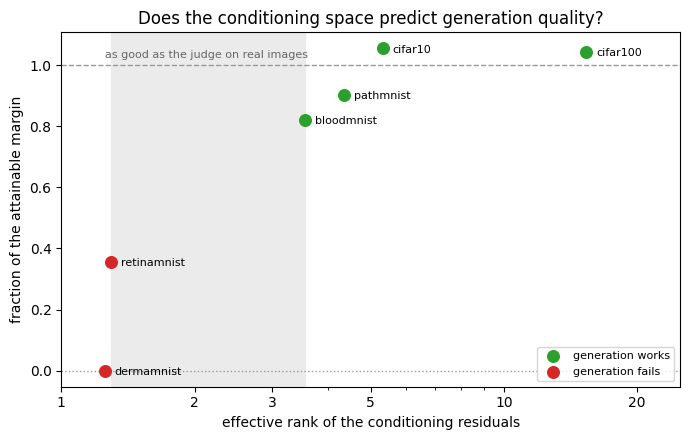

In [6]:
# Accuracy artefacts, named after the parameters each run was launched with.
ACCURACY = {
    "cifar10": "accuracy_steps31_window5.npz",
    "cifar100": "accuracy_steps28_window7.npz",
    "pathmnist": "accuracy_steps48_window12.npz",
    "dermamnist": "accuracy_steps27_window7.npz",
    "bloodmnist": "accuracy_steps44_window11.npz",
    "retinamnist": "accuracy_steps30_window7.npz",
}

names, ranks, quality = [], [], []
print(f"{'dataset':>12} {'rank':>7} {'all':>8} {'chance':>8} "
      f"{'ceiling':>9} {'quality':>9}")

for dataset in ENCODERS:
    space = load(dataset)
    scores = np.load(os.path.join(
        common.results_dir(EXP, dataset, "windows"), ACCURACY[dataset]))

    # Full conditioning is the configuration with the most conditioned steps.
    full = float(scores["accuracy"][np.argmax(scores["counts"])])
    chance = 1 / len(space["labels"])
    ceiling = float(scores["real_accuracy"])

    names.append(dataset)
    ranks.append(float(space["effective_rank"]))
    quality.append((full - chance) / (ceiling - chance))

    print(f"{dataset:>12} {ranks[-1]:>7.2f} {full:>8.1%} {chance:>8.1%} "
          f"{ceiling:>9.1%} {quality[-1]:>9.3f}")

fig = plotting.rank_vs_quality(
    ranks, quality, names,
    title="Does the conditioning space predict generation quality?")
display(fig)
plt.close(fig)

## Conclusion

Starting from mutually orthogonal one-hot vectors, having seen neither words nor
categories, the Class-Encoder arranges its conditioning space so that it
**reproduces the visual geometry of the real dataset**.

| dataset | shared | Mantel | p |
|---|---|---|---|
| bloodmnist | 98.8% | **+0.878** | 0.0001 |
| cifar100 | 97.7% | **+0.459** | 0.0001 |
| cifar10 | 96.6% | **+0.776** | 0.0004 |
| retinamnist | 93.3% | +0.735 | 0.0919 |
| pathmnist | 87.4% | +0.242 | 0.0767 |
| dermamnist | 87.0% | **+0.828** | 0.0216 |

Four datasets out of six reach significance. PathMNIST and RetinaMNIST do not, and
the likely reason on PathMNIST is the descriptor rather than the model: histology
images are textures, which a per-class mean image describes badly. A limitation, not
a refutation.

Three things carry forward from here.

**Conditioning is a global direction.** Between 87% and 99% of it is identical for
every class, and the discriminative part is a small perturbation of a shared vector.
The consequence appears in Result 2: a global vector has nothing to localise, which
is why the cross-attention maps carry no class information — the failure of that axis
is predicted by the geometry measured here.

**What is learned is appearance, not kinship.** BloodMNIST is the proof. The
haematological taxonomy fails while visual similarity gives the strongest correlation
of the six. Giemsa staining exists precisely to make biologically sibling cells look
different — so on that dataset the two references disagree, and the model follows
appearance. The same shows on CIFAR-100, where `clock` and `plate` are close: both
round objects on a plain background, conceptually unrelated.

**How the residual is distributed matters more than how much there is.** DermaMNIST
has the largest residual (13.0%) and the lowest effective rank (1.26), and it is the
dataset where generation fails outright — the images are fluorescent artefacts, not
skin lesions. The separation in the last figure is clean, but it rests on six
datasets with two failures: any threshold between 1.3 and 3.5 would draw the same
line. It is an observation worth reporting and worth testing further, not a law.